# ATMS 523 Homework 2
## Wenhan Tang (UIN: 678054985)

#### Dataset: ERA5 post-processed daily statistics on single levels from 1940 to present
Copernicus Climate Change Service, Climate Data Store, (2024): ERA5 post-processed daily-statistics on single levels from 1940 to present. Copernicus Climate Change Service (C3S) Climate Data Store (CDS), DOI: 10.24381/cds.4991cf48 (Accessed on 23-SEP-2025)

## Import packages

In [1]:
import dask
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Access dataset

In [2]:
start = "2015-01-01 06:00"
end   = "2024-12-31 06:00"
DataDir = "ERA5_precip"
pr = pd.date_range(start=start, end=end, freq="MS")
file_list = []
for dt in pr:
    yearmonth = dt.strftime("%Y%m")
    file_list.append(DataDir + "/ERA5_tp_daily_accumu_" + yearmonth + ".nc")

In [3]:
ds = xr.open_mfdataset(
    file_list,
    engine="h5netcdf", 
    combine="by_coords",
    chunks={"time": 12},
    parallel=False,           # <- important: don't delay opens
)

## Select a 5x5 region

In [4]:
lon_center = -95.5 
lat_center = 37
Region = { # Region around Coffeywille, KS.
    "lon1": lon_center - 2.5,
    "lon2": lon_center + 2.5,
    "lat1": lat_center - 2.5,
    "lat2": lat_center + 2.5,
}
tp_region = ds["tp"].sel(
    latitude = slice(Region["lat2"], Region["lat1"]),
    longitude = slice(Region["lon1"], Region["lon2"])
)
tp_region

<xarray.DataArray 'tp' (valid_time: 3653, latitude: 21, longitude: 21)> Size: 6MB
dask.array<getitem, shape=(3653, 21, 21), dtype=float32, chunksize=(31, 21, 21), chunktype=numpy.ndarray>
Coordinates:
    number      int64 8B 0
  * latitude    (latitude) float64 168B 39.5 39.25 39.0 ... 35.0 34.75 34.5
  * longitude   (longitude) float64 168B -98.0 -97.75 -97.5 ... -93.25 -93.0
  * valid_time  (valid_time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
Attributes: (12/32)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      38157
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                                    m
    standard_name:                            unknown
    GRIB_surface:                             0.0

## Save the precipitation data for that 5x5 region

In [5]:
tp_region.to_netcdf("Precipitation_daily_regional.nc")

## Compute the daily-precipitation 95th percentile and list the extreme days.

In [6]:
tp_daily_mean = tp_region.mean(dim=("latitude", "longitude"), skipna=True)
p95_t = float(tp_daily_mean.quantile(0.95, dim="valid_time", skipna=True).values)
p95_t_mm = p95_t * 1000
vals_t = tp_daily_mean.values * 1000 # convert m -> mm
vals_t_sorted = np.sort(vals_t)
ecdf_t = np.arange(1, vals_t_sorted.size + 1) / vals_t_sorted.size

## Plot CDF of daily regional mean precipitation

Text(13.48606403917074, 0.02, '95th = 13.49 mm/day')

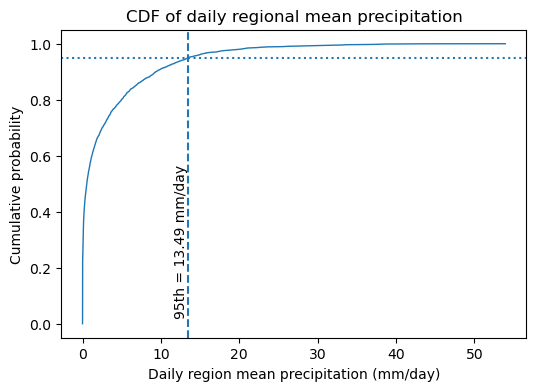

In [7]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(vals_t_sorted, ecdf_t, lw=1)
ax.axvline(p95_t_mm, ls="--")
ax.axhline(0.95, ls=":")
ax.set_xlabel("Daily region mean precipitation (mm/day)")
ax.set_ylabel("Cumulative probability")
ax.set_title("CDF of daily regional mean precipitation")
ax.text(p95_t_mm, 0.02, f"95th = {p95_t_mm:.2f} mm/day", rotation=90, va="bottom", ha="right")

In [8]:
## Select a 40x40 region.

In [9]:
Region_US = { # Continental US.
    "lon1": lon_center - 20,
    "lon2": lon_center + 20,
    "lat1": lat_center - 20,
    "lat2": lat_center + 20,
}
tp_US = ds["tp"].sel(
    latitude = slice(Region_US["lat2"], Region_US["lat1"]),
    longitude = slice(Region_US["lon1"], Region_US["lon2"])
)
tp_US

<xarray.DataArray 'tp' (valid_time: 3653, latitude: 161, longitude: 161)> Size: 379MB
dask.array<getitem, shape=(3653, 161, 161), dtype=float32, chunksize=(31, 161, 161), chunktype=numpy.ndarray>
Coordinates:
    number      int64 8B 0
  * latitude    (latitude) float64 1kB 57.0 56.75 56.5 56.25 ... 17.5 17.25 17.0
  * longitude   (longitude) float64 1kB -115.5 -115.2 -115.0 ... -75.75 -75.5
  * valid_time  (valid_time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
Attributes: (12/32)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      38157
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                                    m
    standard_name:                            unknown
    GRIB_surface:                             0.0

## Composite mean precipitation on the 95% days

In [10]:
extreme_days = tp_daily_mean.where(tp_daily_mean > p95_t).dropna("valid_time")["valid_time"]
average_tp_extreme = tp_US.sel(valid_time = extreme_days).mean(dim = "valid_time", skipna = True)
average_tp_extreme

<xarray.DataArray 'tp' (latitude: 161, longitude: 161)> Size: 104kB
dask.array<mean_agg-aggregate, shape=(161, 161), dtype=float32, chunksize=(161, 161), chunktype=numpy.ndarray>
Coordinates:
    number     int64 8B 0
  * latitude   (latitude) float64 1kB 57.0 56.75 56.5 56.25 ... 17.5 17.25 17.0
  * longitude  (longitude) float64 1kB -115.5 -115.2 -115.0 ... -75.75 -75.5

## Ploting function of 2-D map

In [11]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

vmin = None
vmax = None
cmap = "coolwarm"
def draw_2Dmap(field_2D, cmap, cbar_label, vmin = None, vmax = None):
    proj = ccrs.PlateCarree()
    fig, ax = plt.subplots(figsize=(7,5), subplot_kw=dict(projection=proj))
    lon = field_2D.longitude
    lat = field_2D.latitude
    lon1 = lon.values.min()
    lon2 = lon.values.max()
    lat1 = lat.values.min()
    lat2 = lat.values.max()
    
    ax.set_extent([lon1, lon2, lat1, lat2], crs=proj)
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.7)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)
    ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.3)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = gl.right_labels = False
    im = ax.pcolormesh(lon, lat, field_2D * 1000, transform=proj, shading="auto", vmin=vmin, vmax=vmax, cmap=cmap)
    cbar = plt.colorbar(im, ax=ax, pad=0.02, shrink=0.85)
    #cbar.set_label("Total Precipitation (mm)")
    cbar.set_label(cbar_label)

## Plot the mean precipitation on the 95% days

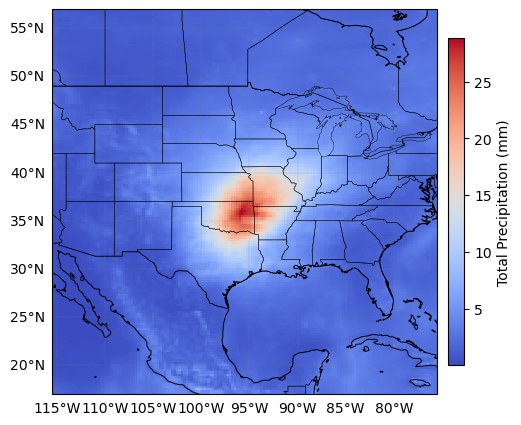

In [12]:
draw_2Dmap(average_tp_extreme, cmap = "coolwarm", cbar_label = "Total Precipitation (mm)")

## Access 30-year monthly precipitation data and compute the climatological mean precipitation.

In [13]:
ds_climate = xr.open_dataset("ERA-5_total_precipitation_monthly-1981-2020.nc")
tp_climate = ds_climate["tp"].sel(
    latitude = slice(Region_US["lat2"], Region_US["lat1"]),
    longitude = slice(Region_US["lon1"]+360, Region_US["lon2"]+360)
).mean(dim = "valid_time")
tp_climate = tp_climate.assign_coords(longitude = tp_climate.longitude - 360)

## Compute the anomaly

In [14]:
tp_extreme_ano = average_tp_extreme - tp_climate

## Plot the anomaly

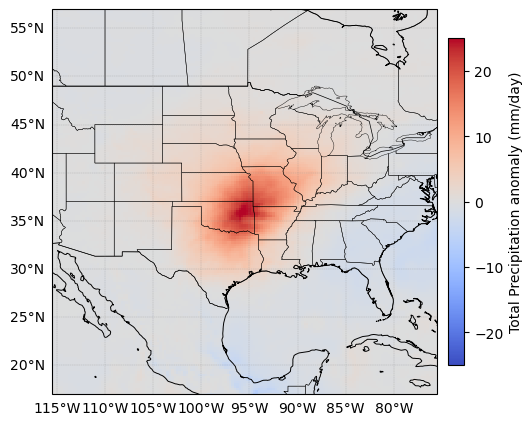

In [15]:
draw_2Dmap(tp_extreme_ano, cmap = "coolwarm", cbar_label = "Total Precipitation anomaly (mm/day)", vmax = 25, vmin = -25)